<a href="https://colab.research.google.com/github/harshpailkar/optiball/blob/main/optiball_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML


def ackley(x, y):
    term1 = ((x ** 2 + y ** 2) * 0.5).sqrt() * -0.2
    term2 = (x.cos(2 * math.pi) + y.cos(2 * math.pi)) * 0.5
    return (term1.exp() * -20.0) - term2.exp() + math.e + 20.0

# for visualization
def ackley_np(x, y):
    return (-20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
            - np.exp(0.5 * (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
            + np.e + 20)

In [2]:
class Value:

  def __init__(self, data, _children=(), _op=''):
      self.data = data
      self.grad = 0
      self._backward = lambda: None
      self._prev = set(_children)
      self._op = _op

  def __add__(self, other):
      other = other if isinstance(other, Value) else Value(other)
      out = Value(self.data + other.data, (self, other), '+')

      def _backward():
          self.grad += out.grad
          other.grad += out.grad
      out._backward = _backward
      return out

  def __mul__(self, other):
      other = other if isinstance(other, Value) else Value(other)
      out = Value(self.data * other.data, (self, other), '*')

      def _backward():
          self.grad += other.data * out.grad
          other.grad += self.data * out.grad
      out._backward = _backward
      return out

  def __pow__(self, other):
      out = Value(self.data ** other, (self,), f'**{other}')

      def _backward():
          self.grad += (other * self.data**(other-1)) * out.grad
      out._backward = _backward
      return out

  def exp(self):
      out = Value(math.exp(self.data), (self,), 'exp')

      def _backward():
          self.grad += out.data * out.grad
      out._backward = _backward
      return out

  def cos(self, freq=1.0):
      x = self.data * freq
      out = Value(math.cos(x), (self,), 'cos')

      def _backward():
          self.grad += (-math.sin(x)*freq) * out.grad
      out._backward = _backward
      return out

  def sqrt(self):
      out = Value(self.data**0.5, (self,), 'sqrt')

      def _backward():
          self.grad += (0.5 * self.data**-0.5) * out.grad
      out._backward = _backward
      return out

  def backward(self):

      topo = []
      visited = set()

      def build(v):
          if v not in visited:
              visited.add(v)
              for c in v._prev:
                  build(c)
              topo.append(v)

      build(self)

      self.grad = 1
      for v in reversed(topo):
          v._backward()

  def __neg__(self): return self * -1
  def __sub__(self, other): return self + (-other)
  def __radd__(self, other): return self + other
  def __rmul__(self, other): return self * other

In [48]:
# initialize marbels

# 1. Vanilla SGD Marble
m_sgd = [Value(-3.0), Value(3.0)]

# 2. Standard Momentum Marble
m_mom = [Value(3.0), Value(3.0)]
v_mom = [0.0, 0.0]

# 3. Nesterov Marble
m_nes = [Value(1.0), Value(1.0)]
v_nes = [0.0, 0.0]

In [49]:
lr = 0.01
beta = 0.9

sgd_path = []
mom_path = []
nes_path = []

for step in range(5000):

    # SGD
    h = ackley(m_sgd[0], m_sgd[1])
    h.backward()
    for p in m_sgd:
        p.data -= lr * p.grad
        p.grad = 0
    sgd_path.append((m_sgd[0].data, m_sgd[1].data))

    # Momentum
    h = ackley(m_mom[0], m_mom[1])
    h.backward()
    for i,p in enumerate(m_mom):
        v_mom[i] = beta*v_mom[i] - lr*p.grad
        p.data += v_mom[i]
        p.grad = 0
    mom_path.append((m_mom[0].data, m_mom[1].data))

    # Nesterov
    for i,p in enumerate(m_nes):
        p.data += beta*v_nes[i]

    h = ackley(m_nes[0], m_nes[1])
    h.backward()

    for i,p in enumerate(m_nes):
        p.data -= beta*v_nes[i]
        v_nes[i] = beta*v_nes[i] - lr*p.grad
        p.data += v_nes[i]
        p.grad = 0

    nes_path.append((m_nes[0].data, m_nes[1].data))


sgd_path = np.array(sgd_path)
mom_path = np.array(mom_path)
nes_path = np.array(nes_path)

In [50]:
x = np.linspace(-5,5,200)
y = np.linspace(-5,5,200)
X,Y = np.meshgrid(x,y)
Z = ackley_np(X,Y)

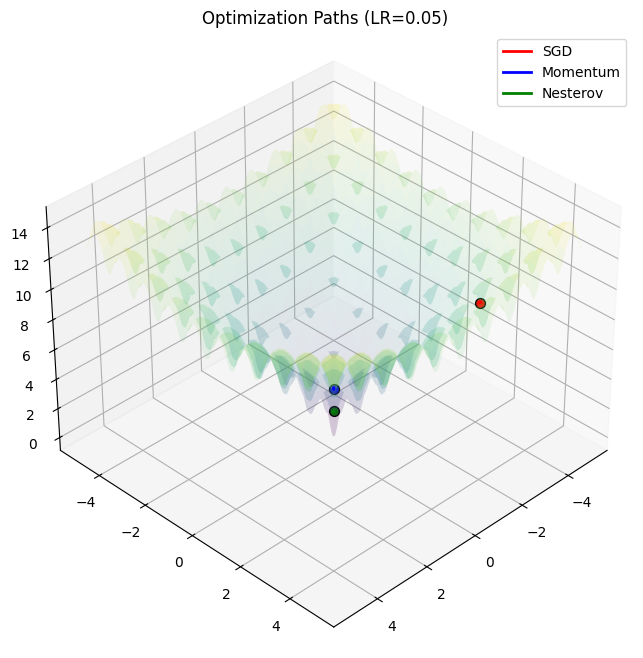

In [51]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.1, rstride=5, cstride=5)

def plot_trajectory(path, color, label):
    xs, ys = path.T
    zs = ackley_np(xs, ys) + 0.15
    ax.plot(xs, ys, zs, color=color, linewidth=2, label=label, zorder=10)
    ax.scatter(xs[-1], ys[-1], zs[-1], color=color, s=50, edgecolors='black', zorder=15)

plot_trajectory(sgd_path, 'red', 'SGD')
plot_trajectory(mom_path, 'blue', 'Momentum')
plot_trajectory(nes_path, 'green', 'Nesterov')

ax.set_title("Optimization Paths (LR=0.05)")
ax.view_init(elev=35, azim=45)
ax.legend()
plt.show()